In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!pip install tensorflow==2.12

In [ ]:
#!unzip "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep.zip" -d "/content/drive/MyDrive/Cheating_enhancement/data/"

In [2]:
%cd /content/drive/MyDrive/Cheating_enhancement/data/data1_oep

/content/drive/MyDrive/Cheating_enhancement/data/data1_oep


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB0

In [4]:
!pwd

/content/drive/MyDrive/Cheating_enhancement/data/data1_oep


In [5]:
#BATCH_SIZE = 32
BATCH_SIZE = 16
IMG_SIZE = [224, 224]
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"

In [6]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Setup directory paths and parameters
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

In [7]:
# Load datasets
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.3,  # 30% for validation
                                             subset='training',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE,
                                                  validation_split=0.2,  # 20% for validation
                                                  subset='validation',
                                                  seed=42)

test_dataset = image_dataset_from_directory(directory,
                                            shuffle=True,
                                            batch_size=BATCH_SIZE,
                                            image_size=IMG_SIZE,
                                            validation_split=0.1,  # 10% for testing
                                            subset='validation',
                                            seed=42)

Found 11581 files belonging to 2 classes.
Using 8107 files for training.
Found 11581 files belonging to 2 classes.
Using 2316 files for validation.
Found 11581 files belonging to 2 classes.
Using 1158 files for validation.


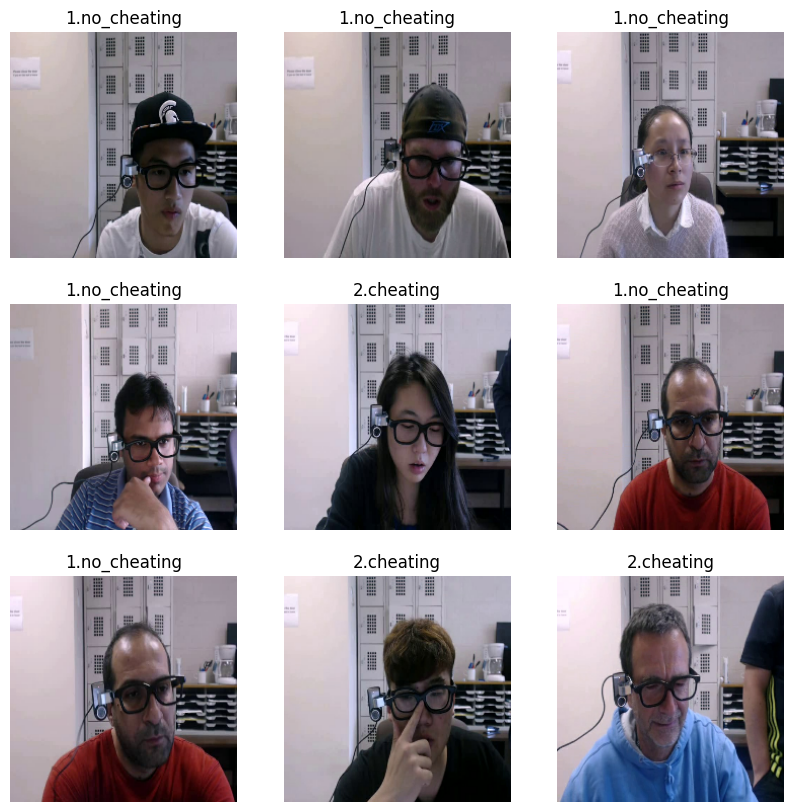

In [8]:
# Display some images
class_names = train_dataset.class_names
num_classes = len(class_names)  # Number of classes
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet101V2
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization, Activation, Dropout

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Dense
from tensorflow.keras.models import Model

# Define input tensor for EfficientNetB0
input_tensor = tf.keras.layers.Input(shape=(224, 224, 3))

# Use EfficientNetB0 as the base model
base_model = EfficientNetB0(include_top=False,
                            weights='imagenet',
                            input_tensor=input_tensor,
                            pooling='max')  # Use global max pooling

# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Create a custom model on top of the base EfficientNetB0
x = base_model.output
x = Dropout(0.4)(x)  # Apply Dropout with 0.4 rate
x = BatchNormalization()(x)  # Apply Batch Normalization
x = Dense(256, activation="relu")(x)  # Dense layer with 256 units and ReLU activation
x = Dense(256, activation="relu")(x)  # Another Dense layer with 256 units and ReLU activation
x = Dropout(0.5)(x)  # Apply Dropout with 0.5 rate
predictions = Dense(1, activation='sigmoid')(x)  # Output layer for classification

# Create the model object
model = Model(inputs=base_model.input, outputs=predictions)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
# Compile the model for binary classification
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
# Import necessary libraries
from tensorflow.keras import callbacks
import time

# Train the model
t1 = time.time()
initial_epochs = 60
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=initial_epochs)
t2 = time.time()
print(f"Training time: {t2 - t1} seconds")


Epoch 1/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 515s 963ms/step - accuracy: 0.7518 - loss: 0.5147 - val_accuracy: 0.8873 - val_loss: 0.2641
Epoch 2/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.8340 - loss: 0.3723 - val_accuracy: 0.9024 - val_loss: 0.2373
Epoch 3/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8607 - loss: 0.3272 - val_accuracy: 0.9016 - val_loss: 0.2434
Epoch 4/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8621 - loss: 0.3140 - val_accuracy: 0.9085 - val_loss: 0.2362
Epoch 5/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8721 - loss: 0.3082 - val_accuracy: 0.9115 - val_loss: 0.2224
Epoch 6/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8823 - loss: 0.2883 - val_accuracy: 0.9136 - val_loss: 0.2174
Epoch 7/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.8757 - loss: 0.2894 - val_accuracy: 0.9167 - val_loss: 0.2091
Epoch 8/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.8926 - loss: 0.2598 

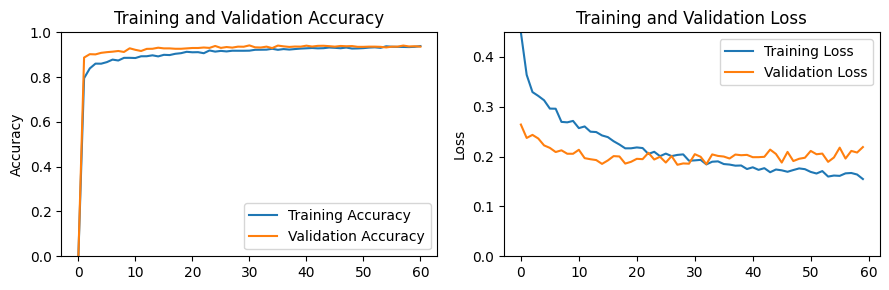

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training and Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training and Validation Loss')
plt.tight_layout()
plt.show()

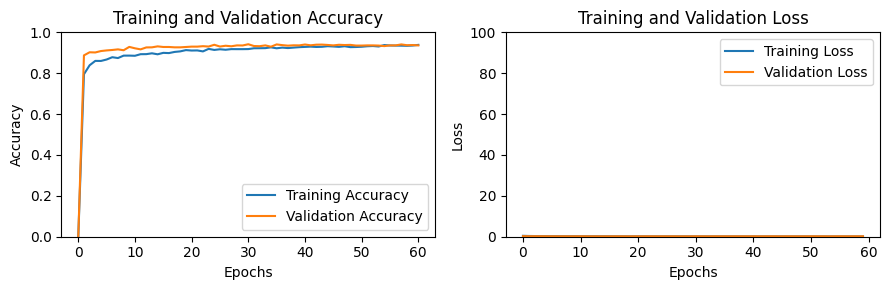

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# Accuracy plot
ax1.plot(range(61), acc, label='Training Accuracy')  # X-axis now spans 61 epochs (0 to 60)
ax1.plot(range(61), val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])  # Keeping accuracy y-axis between min and 1
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')

# Loss plot with adjusted range
ax2.plot(range(60), loss, label='Training Loss')  # Adjusting to ensure it spans the right number of epochs
ax2.plot(range(60), val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, 100])  # Set y-axis of loss plot between 0 and 100
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')

plt.tight_layout()
plt.show()


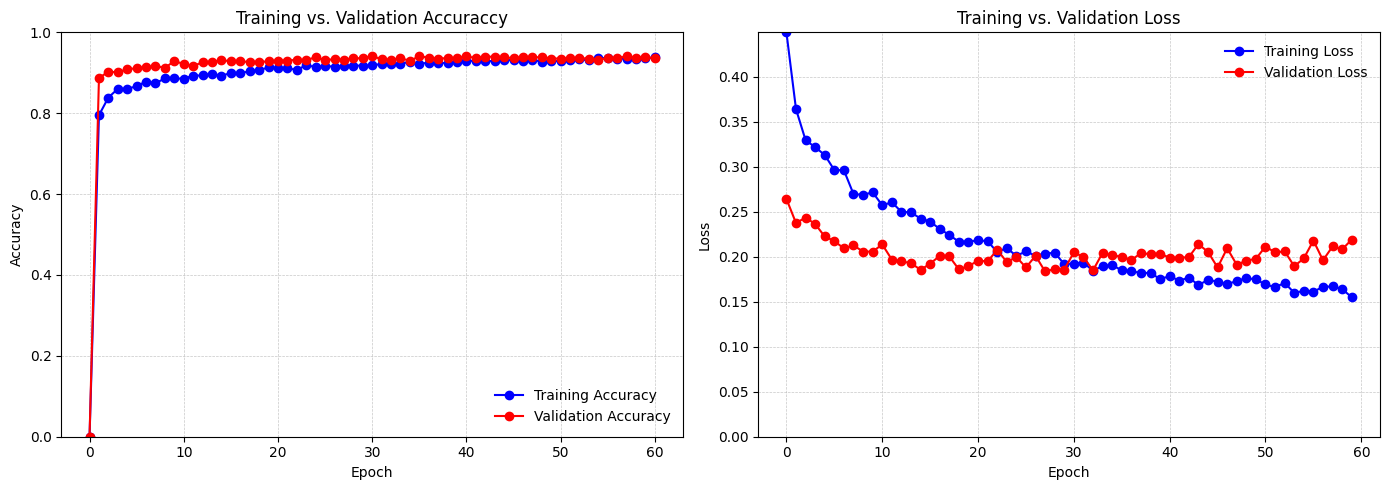

In [ ]:
import matplotlib.pyplot as plt

# Sample Data (replace with your actual history data)
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training and Validation Accuracy Plot
ax1.plot(acc, marker='o', linestyle='-', color='blue', label='Training Accuracy')
ax1.plot(val_acc, marker='o', linestyle='-', color='red', label='Validation Accuracy')
ax1.legend(loc='lower right', fontsize=10, frameon=False)  # Legend inside the plot, lower right
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training vs. Validation Accuraccy')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Training and Validation Loss Plot
ax2.plot(loss, marker='o', linestyle='-', color='blue', label='Training Loss')
ax2.plot(val_loss, marker='o', linestyle='-', color='red', label='Validation Loss')
ax2.legend(loc='upper right', fontsize=10, frameon=False)  # Legend inside the plot, upper right
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training vs. Validation Loss')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Adjust layout and background color
fig.patch.set_facecolor('white')  # Set figure background to white
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to fit everything nicely
plt.show()


In [ ]:
# Evaluate the model
model.evaluate(train_dataset)
model.evaluate(validation_dataset)


507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9689 - loss: 0.0729
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9298 - loss: 0.2307


[0.21900561451911926, 0.936096727848053]

In [ ]:
t3=time.time()
model.evaluate(test_dataset)
t4= time.time()
temps_execution = t4 - t3
print(f"Le temps d'exécution est de {temps_execution} secondes.")

73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.9374 - loss: 0.2289
Le temps d'exécution est de 8.90848994255066 secondes.


In [ ]:
model.evaluate(test_dataset)

73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9379 - loss: 0.2086


[0.25037553906440735, 0.9343696236610413]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Setup directory paths and parameters

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

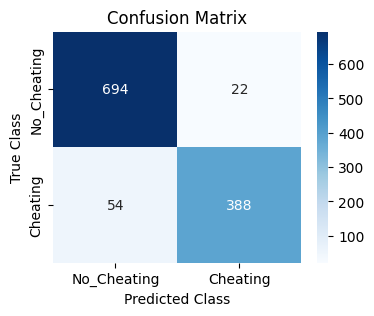

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())  # Get the true labels
    predictions = model.predict(images)  # Get model predictions
    y_pred.extend((predictions > 0.5).astype(int).flatten())  # Threshold for binary classification

# Define binary class names
class_names = ["No_Cheating", "Cheating"]

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))  # Set the figure size to 3x4
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


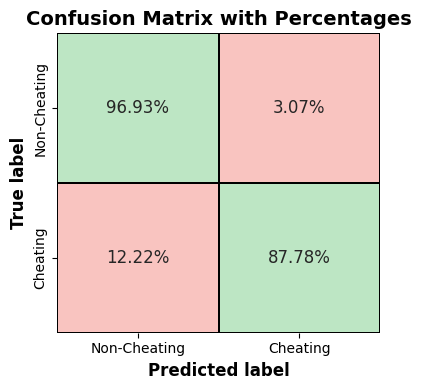

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate the percentages
cf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the labels with percentages
labels = [f'{value:.2f}%' for value in cf_matrix_percent.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels (matching appearance from the previous code)
ax.set_title('Confusion Matrix with Percentages', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


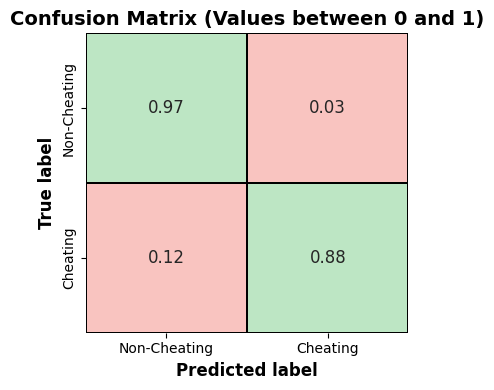

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


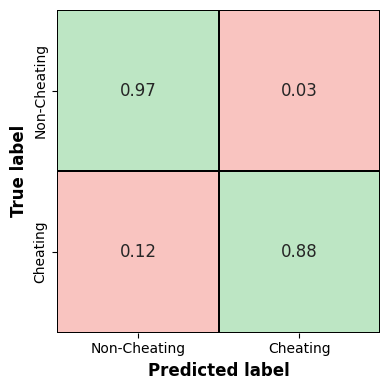

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
#ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already defined

# Calculate accuracy, precision, recall, and f1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='binary')  # Use 'binary' for binary classification, or 'macro', 'micro' for multi-class
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.93
Precision: 0.95
Recall: 0.88
F1 Score: 0.91


AUC for our classifier is: 0.92


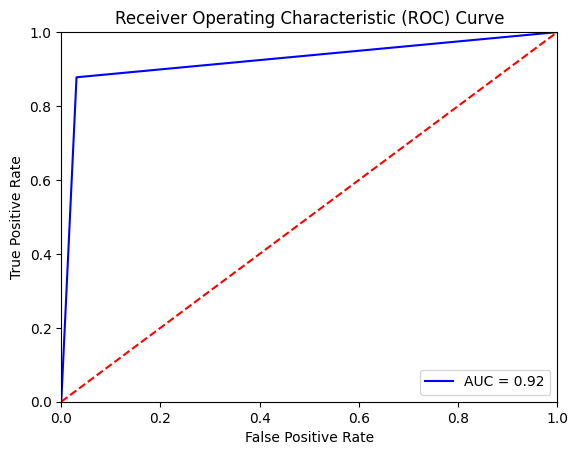

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ROC Curve
fpr, tpr, threshold = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc:.2f}")

# Plotting the ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# Saving the model in HDF5 format
model_save_path = 'saved_models/efficientNetB0_d1.h5'
model.save(model_save_path)

In [ ]:
import tensorflow as tf
%cd /content/drive/MyDrive/Cheating_enhancement/
# Specify the path to the saved model directory
model_path = 'saved_models/efficientNetB0_d1.h5'

# Load the trained model
model = tf.keras.models.load_model(model_path)

# The model is ready to use in inference mode

/content/drive/MyDrive/Cheating_enhancement


In [ ]:
import time

# Initialize variables to accumulate time and count images
total_time = 0
num_images = 0

# Loop over the dataset to measure time for each image
for images, labels in test_dataset:
    start_time = time.time()
    _ = model.evaluate(images, labels, verbose=0)  # Evaluate on a single batch (1 image at a time if batch size is 1)
    end_time = time.time()

    # Accumulate time and count
    total_time += (end_time - start_time)
    num_images += images.shape[0]  # Add number of images in the batch
print(total_time )
print(f"test time: {total_time:.4f} seconds")
print('---------------------')
print( num_images)
print('---------------------')
# Calculate average time per image
average_time_per_image = total_time / num_images
print(f"Average time per image: {average_time_per_image:.4f} seconds")


25.444307804107666
test time: 25.4443 seconds
---------------------
1158
---------------------
Average time per image: 0.0220 seconds


In [ ]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test_dataset)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test_dataset)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


73/73 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step
Total inference time: 193.4946 seconds
Average time per image: 0.1671 seconds


In [12]:
import time

# Limit the test dataset to the first 960 images
test_limited = test_dataset.take(960)

# Start timing
start_time = time.time()

# Run the model on the limited test dataset to get predictions
predictions = model.predict(test_limited)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = 960  # Since we are only taking 960 images

print(f"Total inference time for 960 images: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")

73/73 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step
Total inference time for 960 images: 189.0116 seconds
Average time per image: 0.1969 seconds
